# Noise covariances and the Gaussian likelihood

The Gaussian likelihood of seismic data $d$ given a source $m$ is set by a noise covariance
$C$: $\log L(m) = -\tfrac12 (d - G^\mathsf{T} m)^\mathsf{T} C^{-1} (d - G^\mathsf{T} m)$. This
notebook generates coloured synthetic noise, estimates its covariance, builds every covariance
model the library ships (white, per-station white, three stationary block models, and data
noise plus theory error from an ensemble of Earth models), and compares the posterior each one
gives, by score compression, on data from the reference Earth and from an Earth 1.5 % faster.

**Requirements**: `INSTASEIS_DB` pointing at a local Instaseis database. Nothing is downloaded.
The notebook runs in under a minute.

In [1]:
import os
import tempfile
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

from seismo_sbi.sbi.compression.gaussian import GaussianCompressor, ScoreCompressionData
from seismo_sbi.simulators.instaseis.querier import SYNTHETICS_PRE_EVENT_PAD_S
from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator
from seismo_sbi.simulators.receivers import Receivers
from seismo_sbi.simulators.simulation_io import SimulationDataLoader, seismogram_map_to_array

INSTASEIS_DB = os.environ["INSTASEIS_DB"]
SAMPLING_RATE_HZ = 1.0
DURATION_S = 200
FILTER_BAND = {"type": "bandpass", "freqmin": 0.02, "freqmax": 0.08, "corners": 4, "zerophase": False}
PROCESSING = {"filter": FILTER_BAND, "sampling_rate": SAMPLING_RATE_HZ, "filter_sampling_rate": 5.0}
SOURCE_LOCATION = [37.636, -118.936, 10.0, 0.0]  # latitude, longitude, depth_km, time shift s
TRUE_MOMENT_TENSOR = np.array([1.0e17, -0.6e17, -0.4e17, 0.3e17, -0.5e17, 0.2e17])  # N m
PARAMETER_NAMES = ["m_rr", "m_tt", "m_pp", "m_rt", "m_rp", "m_tp"]
scratch = Path(tempfile.mkdtemp())

## A linear forward model

Five stations record the vertical component. At a fixed location the data are linear in the
moment tensor, $d = G^\mathsf{T} m$, so we take the sensitivity kernels $G$, shape
`(6, n_data)`, from one Instaseis run per unit moment tensor.

In [2]:
receivers = Receivers(receivers=[receiver._replace(components=["Z"]) for receiver in
                                  Receivers.from_station_file("configs/stations.txt").iterate()])
instaseis_simulator = InstaseisSourceSimulator(
    INSTASEIS_DB, components="Z", receivers=receivers,
    seismogram_duration_in_s=DURATION_S, synthetics_processing=PROCESSING)
data_loader = SimulationDataLoader("Z", receivers)




kernels = np.array([seismogram_map_to_array(instaseis_simulator.run_simulation(
    {"source_location": SOURCE_LOCATION, "moment_tensor": list(unit)})[1], receivers)
    for unit in np.eye(6) * 1e17]) / 1e17
n_traces = len(receivers)
trace_length = kernels.shape[1] // n_traces
clean_data = kernels.T @ TRUE_MOMENT_TENSOR
time_after_origin_s = np.arange(trace_length) / SAMPLING_RATE_HZ - SYNTHETICS_PRE_EVENT_PAD_S
print(f"{n_traces} traces of {trace_length} samples; peak signal {np.abs(clean_data).max():.2e} m")

5 traces of 201 samples; peak signal 1.02e-04 m


## Coloured noise and the empirical estimate of its covariance

The "true" noise is stationary with the damped-cosine autocovariance of Kolb et al.,
$c(\tau) = \sigma^2 e^{-\lambda|\tau|}\cos(\lambda\omega_0\tau)$, with a different $\sigma$ at
each station. `BlockDiagonalKolbCovariance` holds it, one Toeplitz block per trace, and its
sampler draws from it. We write 300 noise windows to disk as a noise archive would be, and
`EmpiricalCovarianceEstimator` measures every trace's autocovariance from them.

Computing empirical covariance matrix... 

Done. 

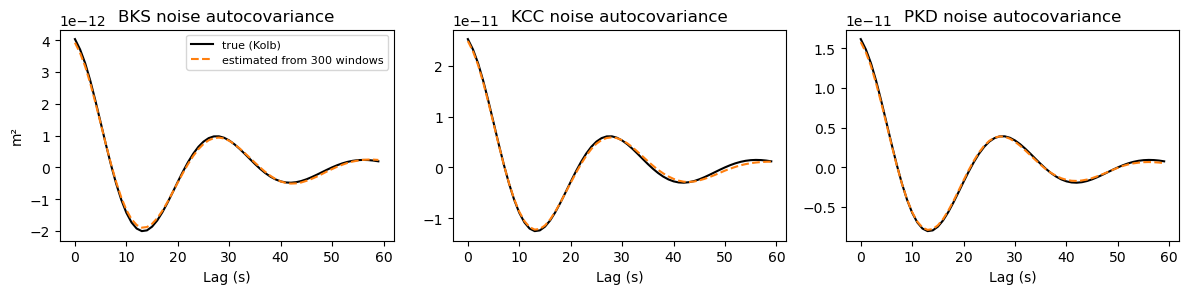

In [3]:
from seismo_sbi.sbi.noises.covariance_estimator import EmpiricalCovarianceEstimator
from seismo_sbi.sbi.noises.toeplitz_covariances import BlockDiagonalKolbCovariance

noise_sigma_m = dict(zip([r.station_name for r in receivers.iterate()], [2e-6, 3e-6, 5e-6, 2.5e-6, 4e-6]))
noise_variances = {station: {"Z": sigma ** 2} for station, sigma in noise_sigma_m.items()}
true_covariance = BlockDiagonalKolbCovariance(noise_variances, receivers=receivers,
                                              data_vector_length=trace_length, num_jobs=1)
true_noise_sampler = true_covariance.create_sampler()

np.random.seed(0)
noise_directory = scratch / "noise"
noise_directory.mkdir()
for window in range(300):
    noise = true_noise_sampler()[0].reshape(n_traces, trace_length)
    with h5py.File(noise_directory / f"noise_{window:03d}.h5", "w") as noise_file:
        for receiver, trace in zip(receivers.iterate(), noise):
            noise_file.create_dataset(f"outputs/{receiver.station_name}/Z", data=trace)

estimated_autocovariances = EmpiricalCovarianceEstimator(
    noise_directory, receivers, "Z", covariance_exp_tapering=False).compute_stationwise_covariances()

lags_s = np.arange(60) / SAMPLING_RATE_HZ
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (index, station) in zip(axes, [(0, "BKS"), (2, "KCC"), (4, "PKD")]):
    ax.plot(lags_s, true_covariance.toeplitz_cols_list[index][:60], "k", label="true (Kolb)")
    ax.plot(lags_s, estimated_autocovariances[station]["Z"][:60], "C1--", label="estimated from 300 windows")
    ax.set_title(f"{station} noise autocovariance")
    ax.set_xlabel("Lag (s)")
axes[0].set_ylabel("m²")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## A theory-error covariance from an ensemble of Earth models

Theory error is the spread of the synthetics over plausible Earth models.
`EnsembleTheoryCovarianceEstimationSimulator` runs any ensemble simulator (a
`GFEnsembleSimulator`) once per member and returns each trace's covariance about the
reference member. Real ensembles are Instaseis or CPS databases built on perturbed 1-D models;
here a toy ensemble stands in for them: each member stretches the time axis of the reference
seismograms, the effect of an Earth uniformly faster or slower by about 1 %.

In [4]:
from seismo_sbi.simulators.gf_ensemble import GFEnsembleSimulator
from seismo_sbi.simulators.theory_covariance import EnsembleTheoryCovarianceEstimationSimulator


def stretch_time_axis(data, velocity_factor):
    """Flat data vector as recorded in an Earth ``velocity_factor`` times faster."""
    return np.concatenate([np.interp(time_after_origin_s * velocity_factor, time_after_origin_s, trace)
                           for trace in data.reshape(n_traces, trace_length)])


class StretchedKernelEnsemble(GFEnsembleSimulator):
    """Kernel seismograms with the time axis stretched by one member's velocity factor."""

    def __init__(self, kernels, velocity_factors, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.kernels = kernels
        self.velocity_factors = list(velocity_factors)

    @property
    def members(self):
        return self.velocity_factors

    @property
    def fiducial_member(self):
        return 1.0

    def generic_point_source_simulation(self, source, use_fiducial=None, **kwargs):
        velocity_factor = self.select_member(use_fiducial=bool(use_fiducial))
        data = stretch_time_axis(self.kernels.T @ source.moment_tensor.components, velocity_factor)
        return {receiver.station_name: {"Z": trace} for receiver, trace
                in zip(self.receivers.iterate(), data.reshape(n_traces, trace_length))}


np.random.seed(1)
ensemble = StretchedKernelEnsemble(kernels, np.random.normal(1.0, 0.01, 30), components="Z",
                                   receivers=receivers, seismogram_duration_in_s=DURATION_S,
                                   synthetics_processing=PROCESSING)
theory_estimator = EnsembleTheoryCovarianceEstimationSimulator(
    ensemble, data_loader.convert_sim_data_to_array, components="Z", receivers=receivers, seismogram_duration_in_s=DURATION_S,
    synthetics_processing=PROCESSING, internal_jobs=1)
theory_blocks = seismogram_map_to_array(theory_estimator.run_simulation(
    {"source_location": SOURCE_LOCATION, "moment_tensor": list(TRUE_MOMENT_TENSOR)})[1], receivers)
print("theory covariance: one", trace_length, "x", trace_length, "block per trace, total size", theory_blocks.size)

theory covariance: one 201 x 201 block per trace, total size 202005


## Every covariance model

| class | noise model | built from |
|---|---|---|
| `ScalarEmpiricalCovariance` | white, one $\sigma$ for all samples | a noise level |
| `DiagonalEmpiricalCovariance` | white, one variance per trace | the estimated lag-0 variances |
| `BlockDiagonalEmpiricalCovariance` | stationary, one Toeplitz block per trace | the estimated autocovariances, tapered by $e^{-\tau/20}$ |
| `BlockDiagonalFilteredCovariance` | band-limited white noise per trace | variances and the filter band |
| `BlockDiagonalKolbCovariance` | damped cosine per trace | variances (the truth here) |
| `TheoryBlockDiagonalEmpiricalCovariance` | data noise plus theory error | theory blocks and a data covariance |

In [5]:
from copy import deepcopy

from seismo_sbi.sbi.noises.covariance_estimator import build_cov_sigma2_dict
from seismo_sbi.sbi.noises.diagonal_covariances import DiagonalEmpiricalCovariance, ScalarEmpiricalCovariance
from seismo_sbi.sbi.noises.theory_block_covariance import TheoryBlockDiagonalEmpiricalCovariance
from seismo_sbi.sbi.noises.toeplitz_covariances import (BlockDiagonalEmpiricalCovariance,
                                                        BlockDiagonalFilteredCovariance)

estimated_variances = build_cov_sigma2_dict(estimated_autocovariances)
estimated_variances_z = [variances["Z"] for variances in estimated_variances.values()]
covariances = {
    "scalar": ScalarEmpiricalCovariance(np.sqrt(np.mean(list(estimated_variances_z))),
                                        data_vector_length=n_traces * trace_length),
    "diagonal": DiagonalEmpiricalCovariance(estimated_autocovariances, receivers, trace_length),
    "empirical": BlockDiagonalEmpiricalCovariance(deepcopy(estimated_autocovariances), receivers,
                                                  trace_length, num_jobs=1),  # it tapers its input in place
    "filtered": BlockDiagonalFilteredCovariance(estimated_variances, FILTER_BAND, receivers,
                                                trace_length, num_jobs=1),
    "Kolb (truth)": true_covariance,
    "theory + Kolb": TheoryBlockDiagonalEmpiricalCovariance(
        ScoreCompressionData(None, theory_blocks, None, None), true_covariance.covariance_matrix_arrays,
        receivers, trace_length, num_jobs=1),
}
for name, covariance in covariances.items():
    print(f"{name:14s} {type(covariance).__name__}")

scalar         ScalarEmpiricalCovariance
diagonal       DiagonalEmpiricalCovariance
empirical      BlockDiagonalEmpiricalCovariance
filtered       BlockDiagonalFilteredCovariance
Kolb (truth)   BlockDiagonalKolbCovariance
theory + Kolb  TheoryBlockDiagonalEmpiricalCovariance


## Observed data and score compression

The observed data are the synthetics of an Earth 1.5 % faster than the reference, plus one draw
of the true noise. `GaussianCompressor` compresses a data vector to
$\hat m = m_\mathrm{fid} + F^{-1}\nabla_m \log L$, with Fisher matrix $F = G C^{-1} G^\mathsf{T}$.
For a linear model $\hat m$ is exactly the maximum-likelihood estimate and $F^{-1}$ the
posterior covariance under a flat prior: the analytical posterior. We check the compressor
against the dense matrix formula once, then ask how far the true source lies from each
posterior's mean, as $\chi^2 = (m_\mathrm{true} - \hat m)^\mathsf{T} F (m_\mathrm{true} - \hat m)$
with 6 degrees of freedom: 95 % of honest posteriors give $\chi^2 < 12.6$.

In [6]:
from scipy.linalg import block_diag

np.random.seed(3)
observed_data = stretch_time_axis(clean_data, 1.015) + true_noise_sampler()[0]
score_compression_data = ScoreCompressionData(
    theta_fiducial=np.zeros(6), data_fiducial=np.zeros(kernels.shape[1]),
    data_parameter_gradients=kernels, second_order_gradients=None)
compressors = {name: GaussianCompressor(score_compression_data, covariance)
               for name, covariance in covariances.items()}

dense_covariance = block_diag(*covariances["empirical"].covariance_matrix_arrays)
weighted_kernels = np.linalg.solve(dense_covariance, kernels.T)
dense_estimate = np.linalg.solve(kernels @ weighted_kernels, weighted_kernels.T @ observed_data)
compressed = compressors["empirical"].compress_data_vector(observed_data)
assert np.allclose(compressed, dense_estimate, rtol=1e-6)
print("score compression equals the dense least-squares solution: True")

analytic_posteriors = {name: (compressor.compress_data_vector(observed_data), compressor.Fisher_mat_inverse)
                       for name, compressor in compressors.items()}
reference_earth_data = clean_data + observed_data - stretch_time_axis(clean_data, 1.015)


def chi2_of_truth(compressor, data):
    offset = TRUE_MOMENT_TENSOR - compressor.compress_data_vector(data)
    return offset @ compressor.Fisher_mat @ offset


print(f"{'':14s} {'posterior std':>14s}  {'chi2 of the truth':^32s}")
print(f"{'covariance':14s} {'of m_rr (N m)':>14s}  {'reference Earth':>16s}{'faster Earth':>16s}")
for name, compressor in compressors.items():
    print(f"{name:14s} {np.sqrt(compressor.Fisher_mat_inverse[0, 0]):14.2e}  "
          f"{chi2_of_truth(compressor, reference_earth_data):16.1f}{chi2_of_truth(compressor, observed_data):16.1f}")

score compression equals the dense least-squares solution: True
                posterior std         chi2 of the truth        
covariance      of m_rr (N m)   reference Earth    faster Earth
scalar               2.67e+15               7.4           642.2
diagonal             2.36e+15               6.7           982.5
empirical            2.62e+15               1.1          1147.8
filtered             4.03e+14             179.3         58201.5
Kolb (truth)         1.96e+15               2.4          2152.5
theory + Kolb        4.93e+15               1.5             1.9


With data from the reference Earth every posterior but the filtered one covers the truth; the
filtered model believes there is no noise outside the pass band and is overconfident. With
data from the faster Earth, every covariance of the data noise alone gives a posterior far too
narrow for where the truth lies. Adding the theory covariance widens the posterior enough to
cover it.